[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Smart Store Analytics**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)


## Project Overview  
The AI Billing Counter Monitor is a computer vision-based system designed to automate the tracking of retail checkout efficiency.  
Using a custom-trained **YOLOv11 segmentation model**, the system identifies and tracks four key entities:
- Staff  
- Customers  
- Items  
- Trolleys  

By defining digital **zones (polygons)** over the billing counter and conveyor belt, the system performs two core functions:

### Live Billing Timer  
Automatically starts a timer when a customer enters the billing zone and stops it when they exit.  
This provides precise transaction time for each customer.

### Automated Item Counter  
Counts every unique item passing through a defined inspection zone on the conveyor belt.  
This generates an accurate **item count per transaction**.

The system provides retailers with **data-driven insights** into checkout speed and operational bottlenecks without requiring manual monitoring.

---

## Real-World Applications  

### Queue Management  
Identifies slow counters and peak hours to improve staffing decisions.

### Loss Prevention  
Compares AI item count with receipts to detect missed scans or theft.

### Customer Experience  
Tracks checkout time to improve service speed and satisfaction.

### Warehouse Sorting  
Counts items on conveyor belts for accurate packaging and shipping.

### Self-Checkout Monitoring  
Detects unscanned items in self-service systems to reduce losses.


---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


In [2]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [3]:
from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['Untitled design (15).mp4'],
    total_images=15,
    out_dir="dataset_Frames",
    jpg_quality=100,
    seed=42
)

[✓] Extracted 15 frames to folder: dataset_Frames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [5]:
from yolo_finetune_utils.coco_yolo_converter.seg_converter import coco_to_yolo_converter

coco_to_yolo_converter(
    json_path="7a4f1cc5-6fa0-4905-a084-5474e3a592cf.json",
    images_dir="dataset_Frames",
    output_dir="yolo_Dataset",
    use_split=True,
    train_ratio=0.9,
    val_ratio=0.1,
    test_ratio=0,
    shuffle=True,
    verbose=True
)

Conversion complete. Stats: {'train': 13, 'val': 1, 'test': 1}


{'stats': {'train': 13, 'val': 1, 'test': 1}, 'output_dir': 'yolo_Dataset'}

# Load and Train YOLO Segmentation Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
# Initialize the Extra Large model
model = YOLO('yolo11n-seg.pt') 

results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    project='/kaggle/working/pi_components',
    name='train_run_4',
    device=0,
    
    # --- AUGMENTATION HAPPENS HERE ---
    degrees=15.0,    # Randomly rotates images up to +/- 15 degrees
    fliplr=0.5,      # 50% chance to flip left-right
    flipud=0.5       # 50% chance to flip upside-down
)

# YOLOv11 Instance Segmentation: Single Frame Inference
 
This script performs **single-frame inference** using a custom-trained YOLOv11 segmentation model.  
It extracts a specific frame from a video and applies instance segmentation to identify and mask waste objects.


0: 384x640 3 Customers, 3 Itemss, 2 Staffs, 1 Trolley, 1545.2ms
Speed: 15.6ms preprocess, 1545.2ms inference, 100.7ms postprocess per image at shape (1, 3, 384, 640)


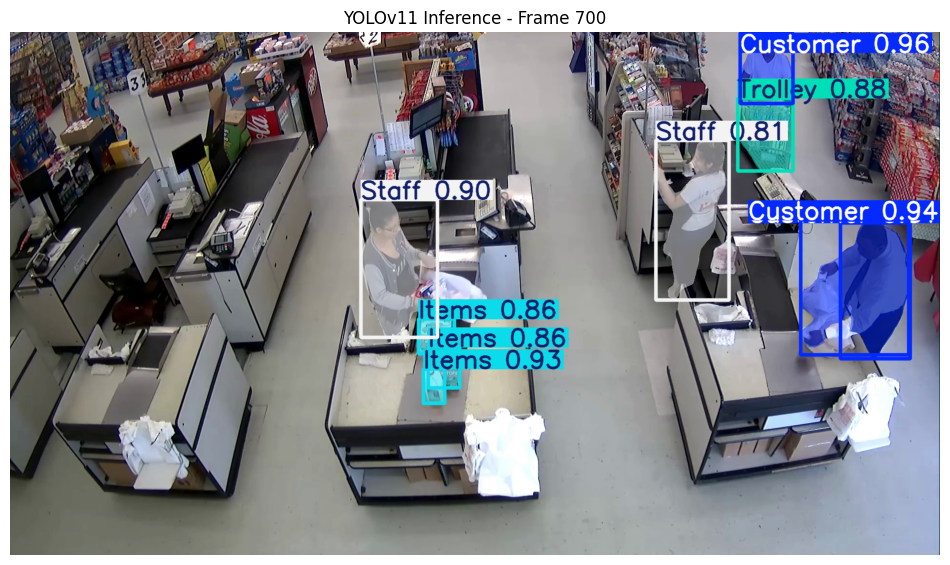

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load your custom trained waste model
model = YOLO('best.pt') 

# 2. Path to your video file
video_path = 'Untitled design (15).mp4'
cap = cv2.VideoCapture(video_path)

# 3. Jump to the 700th frame
frame_no = 700
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
success, frame = cap.read()

if success:
    # 4. Run inference
    results = model.predict(
        source=frame, 
        conf=0.7,
        retina_masks=True,
        show_boxes=False,
        show_labels=True
    )

    # 5. Get the annotated frame (OpenCV uses BGR)
    annotated_frame = results[0].plot()

    # 6. Convert BGR to RGB for Matplotlib (OpenCV colors are swapped)
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # 7. Display directly in VS Code output
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')  # Hide the X and Y axis numbers
    plt.title(f"YOLOv11 Inference - Frame {frame_no}")
    plt.show()
    
else:
    print(f"Error: Frame {frame_no} not found.")

cap.release()

# Raw Inference & Validation

## Overview  
This step performs a **sanity check** on the trained model.  
By running raw inference on the original CCTV footage, the system allows visual verification of model performance before applying additional logic.

---

## Purpose  

- Confirms that the model correctly detects and segments:
  - Staff  
  - Customers  
  - Items  
  - Trolleys  

- Ensures the segmentation quality is accurate and consistent  

- Validates that the model is ready for downstream logic such as:
  - Billing time tracking  
  - Item counting  

---

In [ ]:
from ultralytics import YOLO

# 1. Load your newly trained custom model
# Make sure "best.pt" is in the same directory, or provide the full path
model = YOLO("/kaggle/working/pi_components/train_run_6/weights/best.pt") 

video_path = "/kaggle/input/datasets/aaryanaggarwal5040/billingcounter/Untitled design (15).mp4" # Update this to your actual video file name

print(f"Starting inference on {video_path}...")
results = model.track(
    source=video_path,
    save=True, 
    conf=0.3,
    show_boxes=True,    # Keep this False to hide the rectangles
    show_labels=True,    # Keep this True to see the names
    show_conf=False,
    retina_masks=True,
    stream=True,
    # --- ADD THIS TO SHRINK THE TEXT ---
    line_width=2         # This will make the font significantly smaller and thinner
)

# 3. Execute the video processing loop
# Because stream=True creates a generator, we must iterate through it to process the video
for frame_result in results:
    pass 

print("\nInference complete!")
print("Look for your newly generated video inside the 'runs/segment/predict/' folder.")

# Interactive Zone Calibration

## Overview  
This script acts as a **calibration tool** to define spatial boundaries for the logic engine.  
Since every camera angle is different, it enables manual **polygon mapping** to specify exactly where the AI should monitor specific events.

---

## What This Block Does  

### Manual ROI (Region of Interest) Selection  
Provides an interactive interface to click and define **4-point polygons** for each billing lane.

---

### Coordinate Extraction  
Captures precise pixel coordinates `(x, y)` for:
- Customer standing zones  
- Item inspection belts  

---

### Logic Separation  
Implements a reset mechanism to ensure multiple zones (e.g., Lane 1 vs Lane 2) are stored as **independent polygons** without overlap.

---

### Ground Truth Setup  
The generated coordinates are copied into the main script and used as **trigger zones** for:
- Live billing timers  
- Automated item counters  


In [14]:
import cv2
import numpy as np

# --- SET YOUR VIDEO PATH ---
VIDEO_PATH = "Untitled design (15).mp4" 

all_zones = []  # List of all completed rectangles
current_points = [] # Points for the rectangle currently being drawn

def click_event(event, x, y, flags, params):
    global current_points, img, all_zones
    
    if event == cv2.EVENT_LBUTTONDOWN:
        current_points.append((x, y))
        
        # Draw the point
        cv2.circle(img, (x, y), 4, (0, 0, 255), -1)
        
        # Draw line to previous point in the CURRENT rectangle
        if len(current_points) > 1:
            cv2.line(img, current_points[-2], current_points[-1], (0, 255, 0), 2)
        
        # When we reach 4 points, close the rectangle and SAVE it
        if len(current_points) == 4:
            cv2.line(img, current_points[-1], current_points[0], (0, 255, 0), 2)
            all_zones.append(list(current_points)) # Save a copy of these 4 points
            print(f"Zone {len(all_zones)} Defined: {current_points}")
            current_points = [] # <--- THIS IS THE FIX: Reset for the next zone!
            
        cv2.imshow("Define Zones", img)

cap = cv2.VideoCapture(VIDEO_PATH)
success, img = cap.read()

if not success:
    print("Error: Could not open video.")
else:
    print("--- INSTRUCTIONS ---")
    print("Click 4 points for Zone 1 (Customer L1). It will close automatically.")
    print("Then click 4 points for Zone 2 (Items L1). It won't connect to Zone 1!")
    print("Press 'S' to finish and print all coordinates.")
    
    cv2.imshow("Define Zones", img)
    cv2.setMouseCallback("Define Zones", click_event)
    
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'): # Press 'S' to stop
            print("\nFINAL COORDINATES TO COPY:")
            for i, zone in enumerate(all_zones):
                print(f"Zone {i+1}: {zone}")
            break
        if key == ord('q'):
            break

    cv2.destroyAllWindows()
cap.release()

--- INSTRUCTIONS ---
Click 4 points for Zone 1 (Customer L1). It will close automatically.
Then click 4 points for Zone 2 (Items L1). It won't connect to Zone 1!
Press 'S' to finish and print all coordinates.
Zone 1 Defined: [(1515, 469), (1588, 467), (1574, 426), (1497, 427)]

FINAL COORDINATES TO COPY:
Zone 1: [(1515, 469), (1588, 467), (1574, 426), (1497, 427)]


# Automated Billing Logic & Analytics Engine

## Overview  
This is the **core logic engine** of the project.  
It combines spatial calibration, real-time object tracking, and temporal analysis to convert raw detections into actionable insights such as **service time** and **item throughput**.

Unlike basic inference, this system transforms visual data into measurable retail metrics.

---

## What This Block Does  

### Dual-Lane Processing  
Monitors two independent checkout counters simultaneously using separate **Region of Interest (ROI)** polygons for customers and items.

---

### Spatial Triggering (Center Point Logic)  
Uses the geometric **center point** of detections to trigger events.  
A customer session starts only when their center point enters the predefined standing zone.

---

### Frame-Synchronized Timing  
Calculates service time using video FPS:

`Time = Current Frame ÷ FPS`

This ensures accurate timing regardless of processing speed or hardware performance.

---

### Unique Item Counting  
Uses tracking IDs to ensure each item is counted **only once** as it passes through the inspection zone.  
Prevents duplicate counts for slow or stationary objects.

---

### Real-Time Analytics HUD  
Displays a live dashboard with:
- Current status  
- Billing timer  
- Item count per lane  

The HUD is rendered as a high-contrast overlay for clear visibility.

---

## Technical Goal  

To build a fully automated **checkout auditing system** that measures:
- Staff efficiency  
- Customer wait time  
- Item processing speed  

All without requiring manual supervision.

---

In [ ]:
import cv2
import time
import numpy as np
from ultralytics import YOLO

# --- 1. COORDINATES FROM YOUR CALIBRATION ---
CUST_ZONE_L1 = np.array([(1073, 583), (1329, 562), (1208, 198), (1035, 201)], dtype=np.int32)
ITEM_ZONE_L1 = np.array([(867, 471), (868, 500), (976, 500), (973, 471)], dtype=np.int32)
CUST_ZONE_L2 = np.array([(1675, 506), (1857, 481), (1665, 165), (1488, 195)], dtype=np.int32)
ITEM_ZONE_L2 = np.array([(1515, 469), (1588, 467), (1574, 426), (1497, 427)], dtype=np.int32)

# --- 2. PATHS ---
MODEL_PATH = "/kaggle/working/pi_components/train_run_6/weights/best.pt"
VIDEO_PATH = "/kaggle/input/datasets/aaryanaggarwal5040/billingcounter/Untitled design (15).mp4"
OUTPUT_PATH = "/kaggle/working/billed_analysis.mp4"

def run_billing_system():
    model = YOLO(MODEL_PATH)
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

    stats = {
        "Lane_1": {"start_vtime": None, "total_time": 0, "count": 0, "counted_ids": set(), "active": False},
        "Lane_2": {"start_vtime": None, "total_time": 0, "count": 0, "counted_ids": set(), "active": False}
    }

    frame_count = 0
    print(f"Processing: {total_frames} frames at {fps} FPS...")

    while cap.isOpened():
        success, frame = cap.read()
        if not success: break
        
        frame_count += 1
        current_vtime = frame_count / fps

        results = model.track(frame, persist=True, conf=0.3, verbose=False)
        
        l1_cust_present = False
        l2_cust_present = False

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            ids = results[0].boxes.id.cpu().numpy().astype(int)
            clss = results[0].boxes.cls.cpu().numpy().astype(int)

            for box, obj_id, cls in zip(boxes, ids, clss):
                label = model.names[cls]
                # CENTER POINT LOGIC
                cx, cy = int((box[0] + box[2]) / 2), int((box[1] + box[3]) / 2)
                point = (cx, cy)

                if label == "Customer":
                    if cv2.pointPolygonTest(CUST_ZONE_L1, point, False) >= 0:
                        l1_cust_present = True
                        if stats["Lane_1"]["start_vtime"] is None:
                            stats["Lane_1"]["start_vtime"] = current_vtime
                    
                    if cv2.pointPolygonTest(CUST_ZONE_L2, point, False) >= 0:
                        l2_cust_present = True
                        if stats["Lane_2"]["start_vtime"] is None:
                            stats["Lane_2"]["start_vtime"] = current_vtime

                if label == "Items":
                    if cv2.pointPolygonTest(ITEM_ZONE_L1, point, False) >= 0:
                        if obj_id not in stats["Lane_1"]["counted_ids"]:
                            stats["Lane_1"]["count"] += 1
                            stats["Lane_1"]["counted_ids"].add(obj_id)
                    
                    if cv2.pointPolygonTest(ITEM_ZONE_L2, point, False) >= 0:
                        if obj_id not in stats["Lane_2"]["counted_ids"]:
                            stats["Lane_2"]["count"] += 1
                            stats["Lane_2"]["counted_ids"].add(obj_id)

                # Detection Bounding Boxes
                color = (255, 0, 255) if label == "Customer" else (0, 255, 0)
                cv2.rectangle(frame, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), color, 2)
                cv2.putText(frame, label, (int(box[0]), int(box[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        # Timer Updates
        for lane, is_present in [("Lane_1", l1_cust_present), ("Lane_2", l2_cust_present)]:
            stats[lane]["active"] = is_present
            if is_present:
                stats[lane]["total_time"] = int(current_vtime - stats[lane]["start_vtime"])
            else:
                stats[lane]["start_vtime"] = None

        # --- SOLID BLACK HUD (TOP LEFT) ---
        hud_w, hud_h = 660, 160
        hx, hy = 20, 20 # HUD start position
        
        # Solid Black Rectangle (No transparency for maximum clarity)
        cv2.rectangle(frame, (hx, hy), (hx + hud_w, hy + hud_h), (0, 0, 0), -1)
        cv2.rectangle(frame, (hx, hy), (hx + hud_w, hy + hud_h), (255, 255, 255), 1) # White border

        font = cv2.FONT_HERSHEY_SIMPLEX
        col_w = 330
        
        # Dashboard Content
        # Row 1
        cv2.putText(frame, f"LANE 1 {'(ACTIVE)' if stats['Lane_1']['active'] else ''}", (hx + 20, hy + 45), font, 0.8, (0,255,0), 2)
        cv2.putText(frame, f"LANE 2 {'(ACTIVE)' if stats['Lane_2']['active'] else ''}", (hx + col_w, hy + 45), font, 0.8, (0,255,0), 2)
        # Row 2
        cv2.putText(frame, f"LIVE TIMER: {stats['Lane_1']['total_time']}s", (hx + 20, hy + 90), font, 0.7, (255,255,255), 1)
        cv2.putText(frame, f"LIVE TIMER: {stats['Lane_2']['total_time']}s", (hx + col_w, hy + 90), font, 0.7, (255,255,255), 1)
        # Row 3
        cv2.putText(frame, f"TOTAL ITEMS: {stats['Lane_1']['count']}", (hx + 20, hy + 135), font, 0.7, (255,255,255), 1)
        cv2.putText(frame, f"TOTAL ITEMS: {stats['Lane_2']['count']}", (hx + col_w, hy + 135), font, 0.7, (255,255,255), 1)

        # Visual Zones
        for zone, color in [(CUST_ZONE_L1, (255,0,0)), (ITEM_ZONE_L1, (0,255,255)), (CUST_ZONE_L2, (255,0,0)), (ITEM_ZONE_L2, (0,255,255))]:
            cv2.polylines(frame, [zone], True, color, 2)

        if frame_count % 100 == 0:
            print(f"Frame {frame_count}/{total_frames} ({(frame_count/total_frames)*100:.1f}%)")

        out.write(frame)

    cap.release()
    out.release()
    print("Processing complete.")

if __name__ == "__main__":
    run_billing_system()

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
